/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 496512 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


       id      pesid data_inversa dia_semana   horario  uf     br     km  \
5  496512  1082879.0   2023-01-01    domingo  00:55:00  RS  386.0  353,2   
6  496512  1082877.0   2023-01-01    domingo  00:55:00  RS  386.0  353,2   
7  496512  1082884.0   2023-01-01    domingo  00:55:00  RS  386.0  353,2   
8  496512  1082224.0   2023-01-01    domingo  00:55:00  RS  386.0  353,2   
9  496512  1082880.0   2023-01-01    domingo  00:55:00  RS  386.0  353,2   

  municipio causa_principal  ...       sexo  ilesos feridos_leves  \
5   ESTRELA             Não  ...   Feminino     0.0           0.0   
6   ESTRELA             Não  ...   Feminino     0.0           0.0   
7   ESTRELA             Não  ...  Masculino     0.0           0.0   
8   ESTRELA             Não  ...  Masculino     0.0           0.0   
9   ESTRELA             Não  ...   Feminino     0.0           0.0   

  feridos_graves mortos      latitude     longitude regional delegacia  \
5            1.0    0.0  -29,50160055  -51,94784403  S

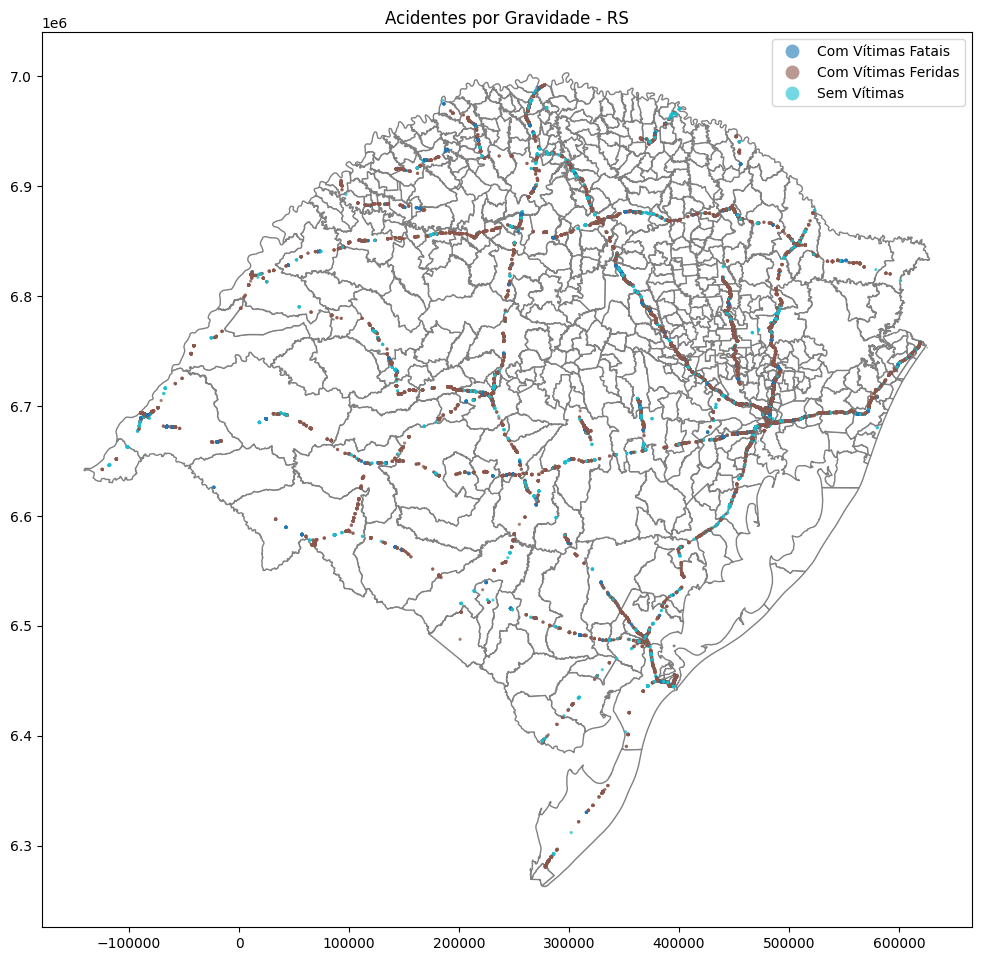

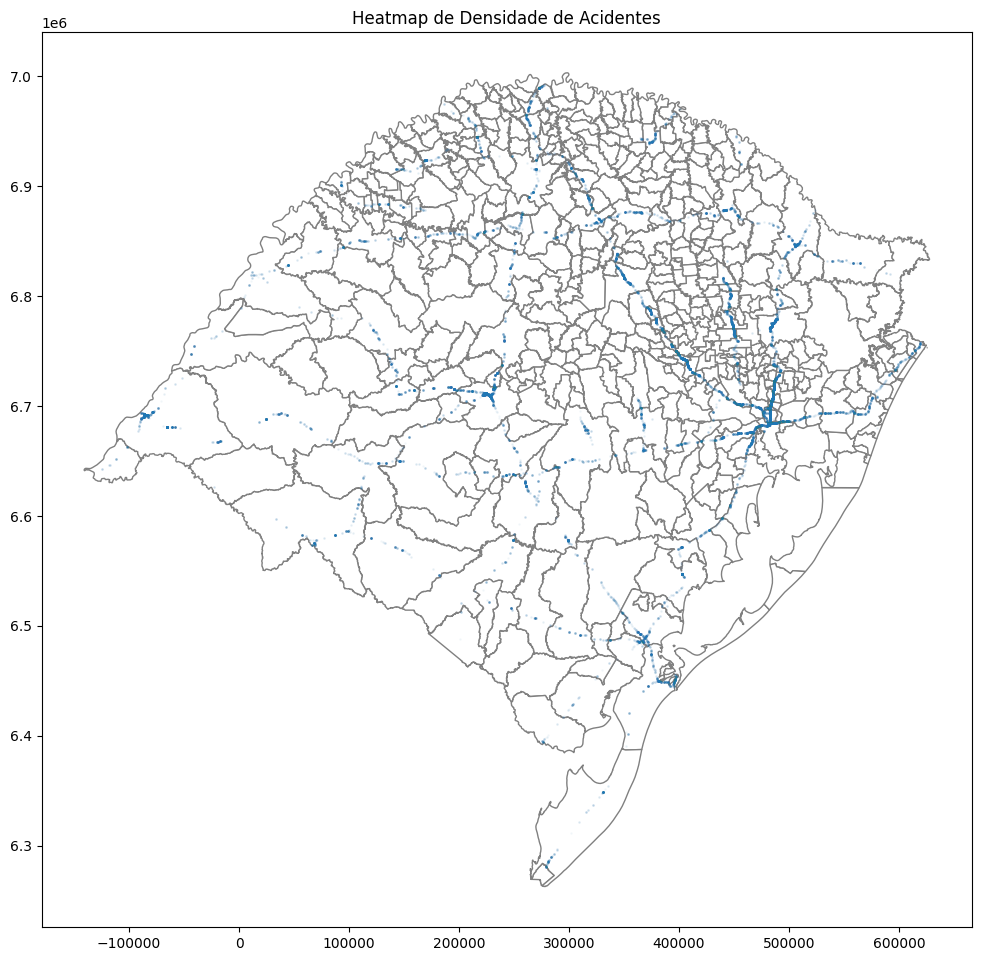

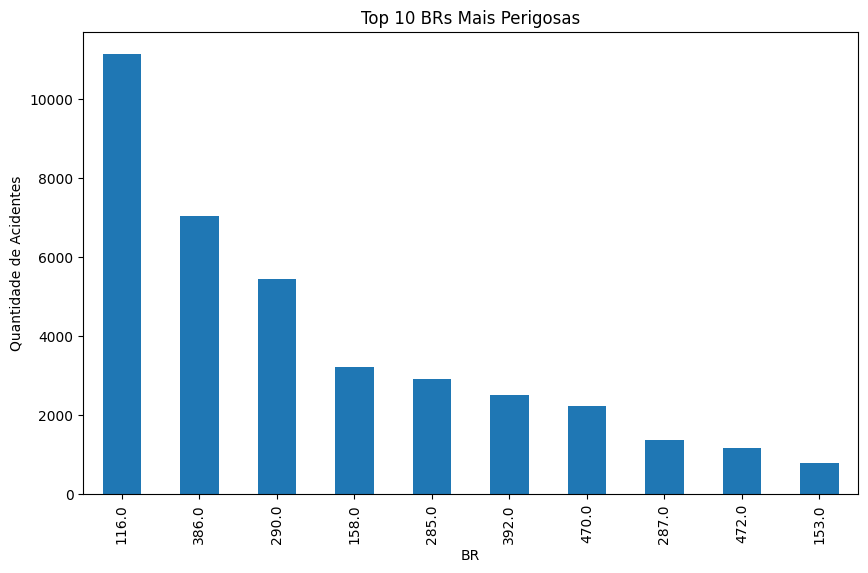

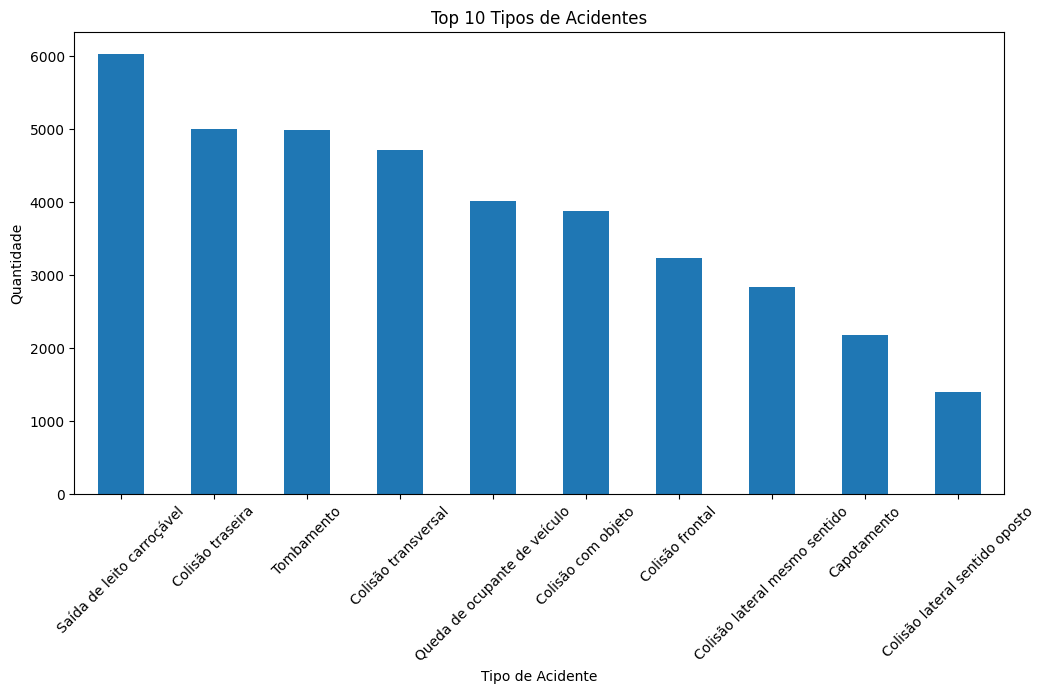

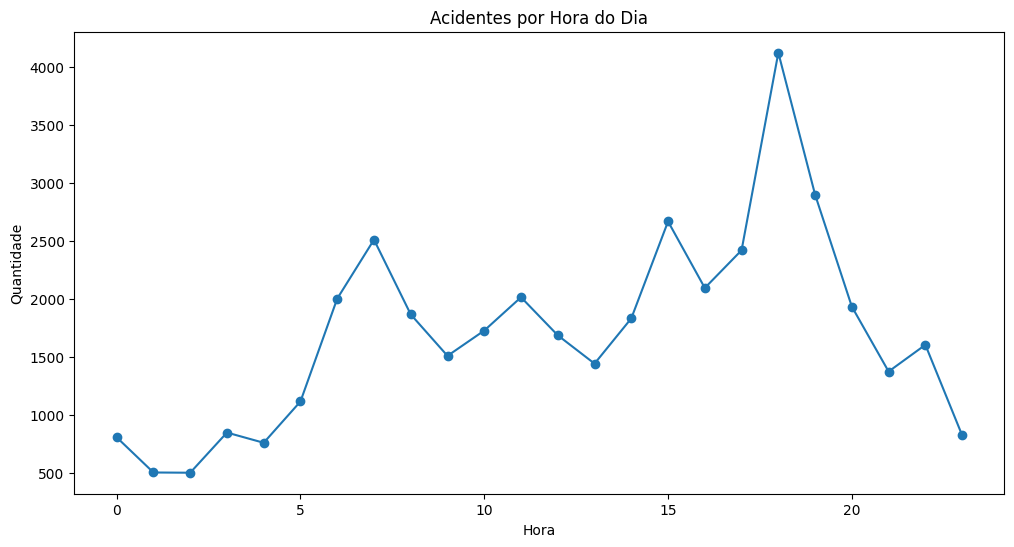

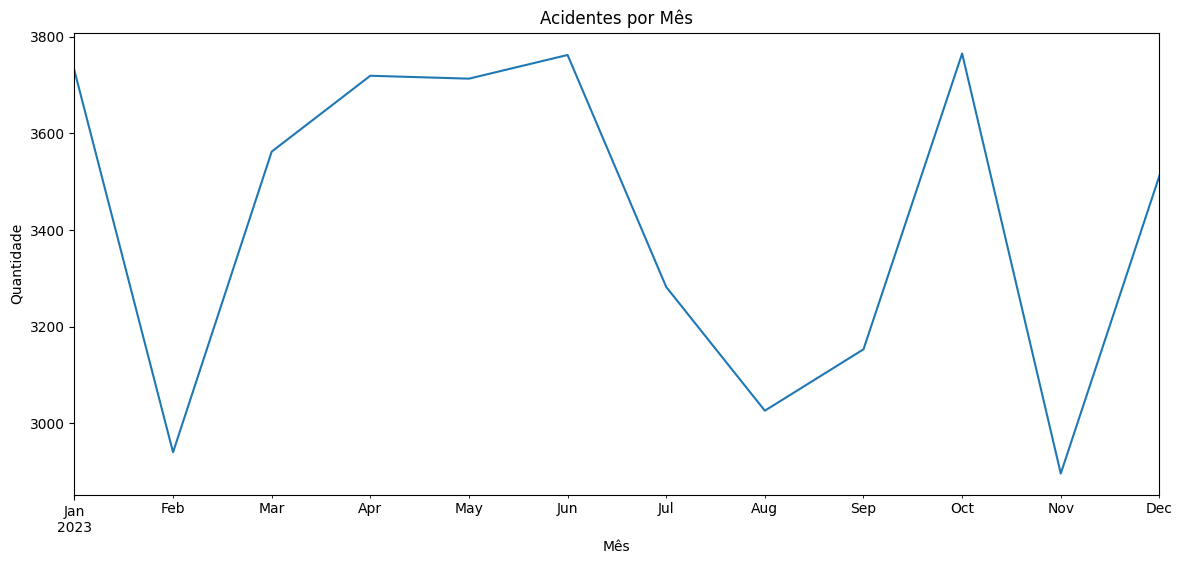

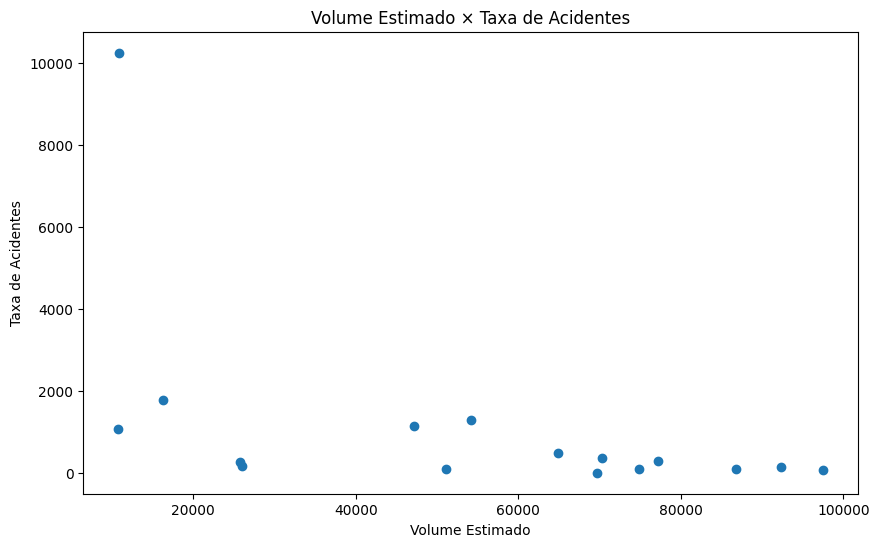

Visualizações exportadas com sucesso!
['horarios_criticos.png', 'serie_temporal.png', 'tipos_acidentes.png', 'scatter_volume_taxa.png', 'top10_brs.png', 'heatmap_acidentes.png', 'mapa_pontos_gravidade.png']


In [2]:
# =========================================
# 0. CRIAR PASTAS
# =========================================

import os

os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/visualizacoes', exist_ok=True)

# =========================================
# 1. IMPORTAR BIBLIOTECAS
# =========================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# 2. CARREGAR DADOS
# =========================================

# CSV ORIGINAL
df = pd.read_csv(
    'acidentes2023.csv',
    sep=';',
    encoding='latin1',
    on_bad_lines='skip',
    engine='python'
)

# FILTRAR RS
df_rs = df[df['uf'] == 'RS'].copy()

# GEOJSONS
joined = gpd.read_file('acidentes-rs.geojson')
municipios = gpd.read_file('municipios-rs.geojson')

print(df_rs.head())
print(joined.head())

# =========================================
# 3. MAPA DE PONTOS POR GRAVIDADE
# =========================================

fig, ax = plt.subplots(figsize=(12,12))

municipios.plot(
    ax=ax,
    color='white',
    edgecolor='gray'
)

joined.plot(
    ax=ax,
    column='classificacao_acidente',
    legend=True,
    markersize=2,
    alpha=0.6
)

plt.title('Acidentes por Gravidade - RS')

plt.savefig(
    'outputs/visualizacoes/mapa_pontos_gravidade.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================
# 4. HEATMAP DE ACIDENTES
# =========================================

fig, ax = plt.subplots(figsize=(12,12))

municipios.plot(
    ax=ax,
    color='white',
    edgecolor='gray'
)

joined.plot(
    ax=ax,
    markersize=1,
    alpha=0.03
)

plt.title('Heatmap de Densidade de Acidentes')

plt.savefig(
    'outputs/visualizacoes/heatmap_acidentes.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================
# 5. TOP 10 BRS MAIS PERIGOSAS
# =========================================

acidentes_br = (
    df_rs.groupby('br')
    .size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10,6))

acidentes_br.head(10).plot(
    kind='bar',
    ax=ax
)

plt.title('Top 10 BRs Mais Perigosas')
plt.xlabel('BR')
plt.ylabel('Quantidade de Acidentes')

plt.savefig(
    'outputs/visualizacoes/top10_brs.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================
# 6. TIPOS DE ACIDENTES
# =========================================

tipos_acidente = (
    df_rs['tipo_acidente']
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(figsize=(12,6))

tipos_acidente.plot(
    kind='bar',
    ax=ax
)

plt.title('Top 10 Tipos de Acidentes')
plt.xlabel('Tipo de Acidente')
plt.ylabel('Quantidade')

plt.xticks(rotation=45)

plt.savefig(
    'outputs/visualizacoes/tipos_acidentes.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================
# 7. HORÁRIOS CRÍTICOS
# =========================================

df_rs['hora_convertida'] = pd.to_datetime(
    df_rs['horario'],
    format='%H:%M:%S',
    errors='coerce'
)

df_rs['hora_num'] = df_rs['hora_convertida'].dt.hour

horarios = (
    df_rs.groupby('hora_num')
    .size()
)

fig, ax = plt.subplots(figsize=(12,6))

horarios.plot(
    kind='line',
    marker='o',
    ax=ax
)

plt.title('Acidentes por Hora do Dia')
plt.xlabel('Hora')
plt.ylabel('Quantidade')

plt.savefig(
    'outputs/visualizacoes/horarios_criticos.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================
# 8. SÉRIE TEMPORAL
# =========================================

df_rs['data_inversa'] = pd.to_datetime(
    df_rs['data_inversa'],
    errors='coerce'
)

df_rs['mes'] = df_rs['data_inversa'].dt.to_period('M')

serie = (
    df_rs.groupby('mes')
    .size()
)

fig, ax = plt.subplots(figsize=(14,6))

serie.plot(ax=ax)

plt.title('Acidentes por Mês')
plt.xlabel('Mês')
plt.ylabel('Quantidade')

plt.savefig(
    'outputs/visualizacoes/serie_temporal.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================
# 9. SCATTER VOLUME × TAXA
# =========================================

correlacao = (
    df_rs.groupby('br')
    .size()
    .reset_index(name='acidentes')
)

np.random.seed(42)

correlacao['volume_estimado'] = np.random.randint(
    10000,
    100000,
    size=len(correlacao)
)

correlacao['taxa_acidentes'] = (
    correlacao['acidentes']
    / correlacao['volume_estimado']
) * 10000

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(
    correlacao['volume_estimado'],
    correlacao['taxa_acidentes']
)

plt.title('Volume Estimado × Taxa de Acidentes')
plt.xlabel('Volume Estimado')
plt.ylabel('Taxa de Acidentes')

plt.savefig(
    'outputs/visualizacoes/scatter_volume_taxa.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================
# 10. FINALIZAÇÃO
# =========================================

print('Visualizações exportadas com sucesso!')

print(os.listdir('outputs/visualizacoes'))